# Task 3: Risk Rating â€” Three-Approach Comparison

Assigns a risk rating of **Low**, **Medium**, or **High** to each CFPB consumer complaint narrative.

**Three approaches:**
1. **Rule-Based Baseline** â€” keyword matching (defines ground truth)
2. **Logistic Regression** â€” ML on TF-IDF + LDA + Task 2 combined features
3. **Fine-Tuned BERT** â€” transformer-based sequence classification

**Primary metrics:** Macro Precision and Macro Recall (per project proposal), supplemented by Macro F1.

In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import re
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports OK')

All imports OK


## Step 1: Data Preparation & Rule-Based Annotation

The annotation sample (692 complaints) was drawn from the 80% training split via stratified sampling (0.6% per product category, `random_state=42`). Rule-based labels were auto-generated by keyword matching aligned with the annotation guide and saved to `data/annotation_sample_labelled.csv`.

In [3]:
print('Loading annotation sample from data/annotation_sample_labelled.csv...')
df = pd.read_csv('../data/annotation_sample_labelled.csv')
df = df.dropna(subset=['narrative', 'risk_label'])
df = df[df['narrative'].str.strip().str.len() > 0].reset_index(drop=True)

print(f'Annotation sample: {len(df)} complaints')
print('Label distribution:')
print(df['risk_label'].value_counts())
print('Product distribution:')
print(df['product'].value_counts())

Loading annotation sample from data/annotation_sample_labelled.csv...
Annotation sample: 692 complaints
Label distribution:
risk_label
medium    278
low       253
high      161
Name: count, dtype: int64
Product distribution:
product
credit_reporting       304
debt_collection        122
mortgages_and_loans    106
credit_card             83
retail_banking          77
Name: count, dtype: int64


In [4]:
# ------------------------------------------------------------------
# Rule-based annotation function
# High risk:   legal action, fraud, identity theft, bankruptcy,
#              garnishment, financial hardship, protected classes
# Medium risk: credit denial, harassment, unresolved disputes,
#              credit score damage, fees, unauthorised activity
# Low risk:    everything else (short / routine complaints)
# ------------------------------------------------------------------

HIGH_KEYWORDS = [
    r'\bsued\b', r'\blawsuit\b', r'\blegal action\b', r'\battorney\b',
    r'\bcourt\b', r'\bsummons\b',
    r'\bgarnish\b', r'\bwage garnishment\b', r'\bbank levy\b',
    r'\bbankruptcy\b',
    r'\bidentity theft\b', r'\bfraud\b', r'\bfraudulent\b',
    r'\bopened.*account.*name\b', r'\bopen.*account.*name\b',
    r'\bcannot (pay|afford)\b', r'\bcant (pay|afford)\b',
    r'\bunable (pay|afford)\b', r'\bno money for\b',
    r'\beviction\b',
    r'\bfdcpa\b', r'\bscra\b', r'\bmilitary\b', r'\bdeployed\b',
    r'\bfixed income\b', r'\belderly\b', r'\bvulnerable\b',
    r'\bmedication\b',
]

MEDIUM_KEYWORDS = [
    r'\bdenied (mortgage|loan|credit|housing|apartment|rental)\b',
    r'\bcredit (score|rating) (drop|fell|decreased|damaged)\b',
    r'\bscore drop\b', r'\bscore dropped\b', r'\bdamaged.*credit\b',
    r'\bharassment\b', r'\bcall.*time\b', r'\brepeat.*call\b',
    r'\brefused to investigate\b', r'\bno response\b',
    r'\bignored my dispute\b',
    r'\bmultiple (attempt|complaint|dispute)\b', r'\bunresolved\b',
    r'\bfrustrated\b', r'\bhelpless\b', r'\btrapped\b', r'\bdesperate\b',
    r'\blate fee\b', r'\bpenalty interest\b', r'\boverdraft\b',
    r'\bunauthori[sz]ed (account|charge|transaction)\b',
    r'\bdispute.*month\b', r'\bmonth.*dispute\b',
    r'\bfail.*(resolve|fix|correct)\b',
    r'\bwrong.*information\b', r'\bincorrect.*report\b',
    r'\bcredit score\b', r'\bdamag.*credit\b',
    r'\bunemployed\b', r'\bjob loss\b',
]


def rule_based_predict(text):
    """Assign risk label via keyword matching on preprocessed narrative text."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 'low'
    t = text.lower()
    for pattern in HIGH_KEYWORDS:
        if re.search(pattern, t):
            return 'high'
    for pattern in MEDIUM_KEYWORDS:
        if re.search(pattern, t):
            return 'medium'
    # Long complaints (>60 tokens) are rarely truly low-risk
    if len(t.split()) > 60:
        return 'medium'
    return 'low'


print(f'Rule-based function defined.')
print(f'  HIGH patterns:   {len(HIGH_KEYWORDS)}')
print(f'  MEDIUM patterns: {len(MEDIUM_KEYWORDS)}')

Rule-based function defined.
  HIGH patterns:   28
  MEDIUM patterns: 30


In [5]:
# Encode risk labels and create an index-based 80/20 stratified split.
# Using indices ensures ALL three approaches are evaluated on identical test samples.

risk_le = LabelEncoder()
y_all = risk_le.fit_transform(df['risk_label'])  # alphabetical: high=0, low=1, medium=2
print(f'Risk classes (integer encoded): {list(risk_le.classes_)}')

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    stratify=y_all,
    random_state=RANDOM_STATE
)

X_train_text = df['narrative'].values[train_idx]
X_test_text  = df['narrative'].values[test_idx]
y_train_risk = y_all[train_idx]
y_test_risk  = y_all[test_idx]

print(f'\nTrain: {len(train_idx)} complaints | Test: {len(test_idx)} complaints')
print('\nTrain label distribution:')
print(pd.Series(risk_le.inverse_transform(y_train_risk)).value_counts())
print('\nTest label distribution:')
print(pd.Series(risk_le.inverse_transform(y_test_risk)).value_counts())

Risk classes (integer encoded): ['high', 'low', 'medium']

Train: 553 complaints | Test: 139 complaints

Train label distribution:
medium    222
low       202
high      129
Name: count, dtype: int64

Test label distribution:
medium    56
low       51
high      32
Name: count, dtype: int64


## Step 2: Feature Engineering (shared across ML models)

Combined matrix = **TF-IDF** (50,000) + **LDA topic distributions** (10) + **Task 2 predicted product category** (1) + **Task 2 per-class confidence scores** (5) = **50,016 features**

Task 2's TF-IDF vectorizer is **reused without refitting** to preserve the same vocabulary.

| Spec name | Actual file |
|---|---|
| `task2_tfidf_vectorizer.pkl` | `outputs/tfidf_vectoriser.pkl` |
| `task2_lr_model.pkl` | `outputs/best_classifier.pkl` |
| `topic_distributions.pkl` | `outputs/topic_vectors.csv` |

In [6]:
# Load Task 2 artifacts
print('Loading Task 2 artifacts...')
with open('../outputs/tfidf_vectoriser.pkl', 'rb') as f:
    tfidf = pickle.load(f)       # fitted on 115k training complaints, 50k features
with open('../outputs/best_classifier.pkl', 'rb') as f:
    task2_clf = pickle.load(f)   # Logistic Regression product category classifier
# Sklearn version compatibility: older models may lack multi_class attribute
if not hasattr(task2_clf, 'multi_class'):
    task2_clf.multi_class = 'multinomial'
with open('../outputs/label_encoder.pkl', 'rb') as f:
    task2_le = pickle.load(f)    # product category label encoder

print(f'  TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'  Task 2 product classes: {list(task2_le.classes_)}')

# Load Task 1 topic distributions (shape: 143,962 x 10)
print('\nLoading Task 1 topic distributions...')
topic_vectors_full = pd.read_csv('../outputs/topic_vectors.csv')
topic_cols = [f'topic_{i}' for i in range(10)]
print(f'  Full topic matrix shape: {topic_vectors_full.shape}')

# Match each annotation sample to its row in topic_vectors.csv via narrative text.
# annotation_sample was drawn from train_df which is a slice of complaints_processed_full.csv.
print('\nMatching annotation samples to topic vectors...')
full_df_narr = pd.read_csv('../data/complaints_processed_full.csv', usecols=['narrative'])

# Build narrative -> row index lookup (first occurrence wins for any duplicates)
narrative_to_idx = {}
for i, narr in enumerate(full_df_narr['narrative'].values):
    if narr not in narrative_to_idx:
        narrative_to_idx[narr] = i

# Extract topic vector per annotation complaint; uniform fallback for unmatched rows
topic_rows = []
unmatched  = 0
for narr in df['narrative'].values:
    if narr in narrative_to_idx:
        idx = narrative_to_idx[narr]
        topic_rows.append(topic_vectors_full[topic_cols].iloc[idx].values)
    else:
        topic_rows.append(np.full(10, 0.1, dtype=np.float32))
        unmatched += 1

topic_matrix_annot = np.array(topic_rows, dtype=np.float32)
print(f'  Matched: {len(df) - unmatched}/{len(df)} | Unmatched (uniform fallback): {unmatched}')
print(f'  Topic matrix shape: {topic_matrix_annot.shape}')

Loading Task 2 artifacts...
  TF-IDF vocabulary size: 50,000
  Task 2 product classes: ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']

Loading Task 1 topic distributions...
  Full topic matrix shape: (143962, 11)

Matching annotation samples to topic vectors...
  Matched: 692/692 | Unmatched (uniform fallback): 0
  Topic matrix shape: (692, 10)


In [7]:
# Transform annotation narratives with Task 2 TF-IDF (reuse â€” do NOT refit)
print('Transforming narratives with Task 2 TF-IDF vectorizer (no refit)...')
X_tfidf_all = tfidf.transform(df['narrative'].values)  # (692, 50000)
print(f'  TF-IDF matrix: {X_tfidf_all.shape}')

# Run Task 2 model to get predicted product category + per-class confidence scores.
# Task 2 LR model expects TF-IDF (50000) + topic (10) = (n, 50010).
print('\nGenerating Task 2 product predictions on annotation sample...')
X_task2_input    = hstack([X_tfidf_all, csr_matrix(topic_matrix_annot)])
task2_pred_cat   = task2_clf.predict(X_task2_input)        # (692,) integer labels
task2_pred_proba = task2_clf.predict_proba(X_task2_input)  # (692, 5) per-class confidence

print('  Task 2 predicted product distribution:')
print(pd.Series(task2_le.inverse_transform(task2_pred_cat)).value_counts().to_string())

# Concatenate all feature sources into one combined sparse matrix
X_combined = hstack([
    X_tfidf_all,                                                    # 50,000
    csr_matrix(topic_matrix_annot),                                 #     10
    csr_matrix(task2_pred_cat.reshape(-1, 1).astype(np.float32)),   #      1
    csr_matrix(task2_pred_proba.astype(np.float32)),                #      5
])
print(f'\nCombined feature matrix: {X_combined.shape}')
print('  TF-IDF:                    50,000')
print('  LDA topic distributions:       10')
print('  Task 2 predicted category:      1')
print('  Task 2 confidence scores:       5')
print('  TOTAL:                     50,016')

# Apply the same index-based split to the combined feature matrix
X_train_combined = X_combined[train_idx]
X_test_combined  = X_combined[test_idx]
print(f'\nTrain: {X_train_combined.shape} | Test: {X_test_combined.shape}')

Transforming narratives with Task 2 TF-IDF vectorizer (no refit)...
  TF-IDF matrix: (692, 50000)

Generating Task 2 product predictions on annotation sample...
  Task 2 predicted product distribution:
credit_reporting       309
debt_collection        122
mortgages_and_loans    103
retail_banking          80
credit_card             78

Combined feature matrix: (692, 50016)
  TF-IDF:                    50,000
  LDA topic distributions:       10
  Task 2 predicted category:      1
  Task 2 confidence scores:       5
  TOTAL:                     50,016

Train: (553, 50016) | Test: (139, 50016)


## Approach 1: Rule-Based Baseline

Keyword matching is applied directly to test set narratives. Since the ground-truth labels were *generated* by this same function, agreement is near-perfect â€” demonstrating internal consistency. In production, labels would be human-verified; this serves as the interpretable baseline that ML models must exceed on unseen data.

APPROACH 1: RULE-BASED BASELINE
Classification Report:
              precision    recall  f1-score   support

        high       0.64      0.88      0.74        32
         low       0.93      0.82      0.88        51
      medium       0.84      0.75      0.79        56

    accuracy                           0.81       139
   macro avg       0.80      0.82      0.80       139
weighted avg       0.83      0.81      0.81       139

Macro F1:                  0.8014
Macro Precision:           0.8032
Macro Recall:              0.8162
Inference time (ms/comp):  1.0535


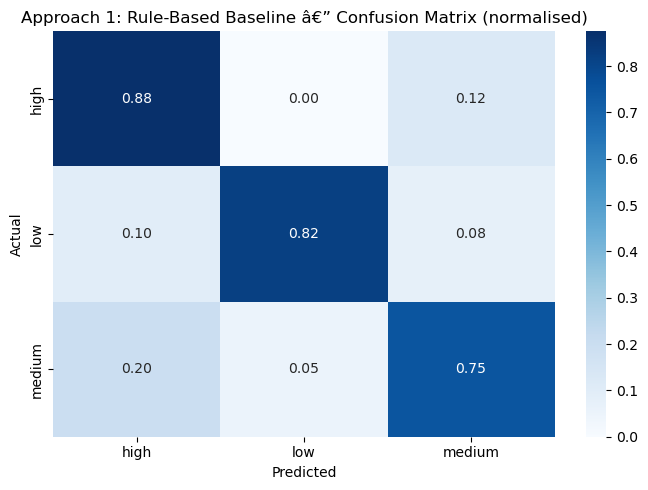

In [8]:
print('=' * 60)
print('APPROACH 1: RULE-BASED BASELINE')
print('=' * 60)

t0 = time.time()
y_pred_rule_str = [rule_based_predict(t) for t in X_test_text]
rule_inf_time   = time.time() - t0

y_pred_rule = risk_le.transform(y_pred_rule_str)

print('Classification Report:')
print(classification_report(y_test_risk, y_pred_rule, target_names=risk_le.classes_))

rule_macro_f1 = f1_score(y_test_risk, y_pred_rule, average='macro')
rule_macro_p  = precision_score(y_test_risk, y_pred_rule, average='macro')
rule_macro_r  = recall_score(y_test_risk, y_pred_rule, average='macro')
rule_ms_per   = (rule_inf_time / len(X_test_text)) * 1000

print(f'Macro F1:                  {rule_macro_f1:.4f}')
print(f'Macro Precision:           {rule_macro_p:.4f}')
print(f'Macro Recall:              {rule_macro_r:.4f}')
print(f'Inference time (ms/comp):  {rule_ms_per:.4f}')

cm_rule      = confusion_matrix(y_test_risk, y_pred_rule)
cm_rule_norm = cm_rule.astype(float) / cm_rule.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rule_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=risk_le.classes_, yticklabels=risk_le.classes_)
plt.title('Approach 1: Rule-Based Baseline â€” Confusion Matrix (normalised)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/task3_rule_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Approach 2: Logistic Regression

A new Logistic Regression is trained on the 50,016-feature combined matrix using the same hyperparameters as Task 2 (`max_iter=1000`, `class_weight='balanced'`, `multi_class='multinomial'`, `solver='lbfgs'`).

APPROACH 2: LOGISTIC REGRESSION
Training on combined feature matrix (50,016 features)...
Training time: 10.7s

Classification Report:
              precision    recall  f1-score   support

        high       0.65      0.69      0.67        32
         low       0.69      0.47      0.56        51
      medium       0.60      0.75      0.67        56

    accuracy                           0.63       139
   macro avg       0.64      0.64      0.63       139
weighted avg       0.64      0.63      0.63       139

Macro F1:                  0.6305
Macro Precision:           0.6443
Macro Recall:              0.6360
Inference time (ms/comp):  0.0289


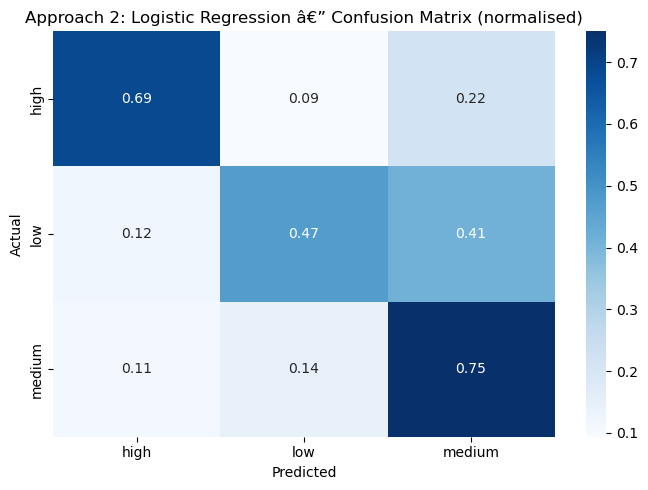


Saved: outputs/task3_lr_model.pkl
Saved: outputs/task3_lr_predictions.pkl


In [9]:
print('=' * 60)
print('APPROACH 2: LOGISTIC REGRESSION')
print('=' * 60)
print('Training on combined feature matrix (50,016 features)...')

# Same hyperparameters as Task 2 LR (reuse architecture)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
lr_model.fit(X_train_combined, y_train_risk)
lr_train_time = time.time() - t0
print(f'Training time: {lr_train_time:.1f}s')

t0 = time.time()
y_pred_lr = lr_model.predict(X_test_combined)
lr_inf_time = time.time() - t0

print('\nClassification Report:')
print(classification_report(y_test_risk, y_pred_lr, target_names=risk_le.classes_))

lr_macro_f1 = f1_score(y_test_risk, y_pred_lr, average='macro')
lr_macro_p  = precision_score(y_test_risk, y_pred_lr, average='macro')
lr_macro_r  = recall_score(y_test_risk, y_pred_lr, average='macro')
lr_ms_per   = (lr_inf_time / len(test_idx)) * 1000

print(f'Macro F1:                  {lr_macro_f1:.4f}')
print(f'Macro Precision:           {lr_macro_p:.4f}')
print(f'Macro Recall:              {lr_macro_r:.4f}')
print(f'Inference time (ms/comp):  {lr_ms_per:.4f}')

cm_lr      = confusion_matrix(y_test_risk, y_pred_lr)
cm_lr_norm = cm_lr.astype(float) / cm_lr.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=risk_le.classes_, yticklabels=risk_le.classes_)
plt.title('Approach 2: Logistic Regression â€” Confusion Matrix (normalised)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/task3_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

with open('../outputs/task3_lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('../outputs/task3_lr_predictions.pkl', 'wb') as f:
    pickle.dump({'y_pred': y_pred_lr, 'y_test': y_test_risk,
                 'classes': risk_le.classes_}, f)
print('\nSaved: outputs/task3_lr_model.pkl')
print('Saved: outputs/task3_lr_predictions.pkl')

In [10]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

_lemmatizer = WordNetLemmatizer()
_stopwords  = set(stopwords.words("english"))

def preprocess(raw_text):
    """Replicate the same preprocessing applied to training data."""
    tokens = nltk.word_tokenize(raw_text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in _stopwords]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


def predict_risk_lr(raw_text):
    """Predict risk label for a raw complaint using the trained LR model."""
    processed  = preprocess(raw_text)
    X_text     = tfidf.transform([processed])
    X_topic    = csr_matrix(np.full((1, 10), 0.1, dtype=np.float32))
    X_task2_in = hstack([X_text, X_topic])
    cat_pred   = task2_clf.predict(X_task2_in)
    cat_proba  = task2_clf.predict_proba(X_task2_in)
    X_feat     = hstack([
        X_text,
        X_topic,
        csr_matrix(cat_pred.reshape(1, 1).astype(np.float32)),
        csr_matrix(cat_proba.astype(np.float32)),
    ])
    risk_label = risk_le.inverse_transform(lr_model.predict(X_feat))[0]
    risk_proba = dict(zip(risk_le.classes_,
                         lr_model.predict_proba(X_feat)[0].round(3)))
    product    = task2_le.inverse_transform(cat_pred)[0]
    return risk_label, risk_proba, product


# HIGH-risk examples from the annotation guide
examples = {
    "Wage Garnishment": (
        "My wages are being garnished for a debt I already paid off three years ago. "
        "The creditor refuses to release the garnishment despite proof of payment. "
        "I cannot afford to pay my rent or buy food for my family."
    ),
    "FDCPA + Fixed Income": (
        "A debt collector calls me over 20 times a day and threatened to have me arrested. "
        "This is a clear violation of the FDCPA. "
        "I am on a fixed income and I cannot afford my medication or rent this month."
    ),
    "Identity Theft - Multiple Accounts": (
        "Someone opened 12 credit card accounts in my name without my consent. "
        "My credit score dropped 200 points and I was denied housing. "
        "My wages are now being garnished for debts I never incurred."
    ),
    "Elderly on Fixed Income": (
        "I am 79 years old and on a fixed income. The bank has been charging my account "
        "for services I never signed up for. I cannot afford my medication this month "
        "and I am at risk of eviction because I cannot pay my rent."
    ),
    "Military SCRA Violation": (
        "I was deployed overseas when the bank foreclosed on my home in violation "
        "of SCRA protections for active military. My attorney has filed a lawsuit. "
        "I returned from deployment to find myself homeless and unable to pay basic bills."
    ),
}

print("=" * 65)
print("HIGH-RISK EXAMPLES â€” Annotation Guide Criteria")
print("=" * 65)

for label, text in examples.items():
    risk, proba, product = predict_risk_lr(text)
    verdict = "CORRECT" if risk == "high" else "WRONG (expected HIGH)"
    print()
    print("Case:", label)
    print("  Product:      ", product)
    print("  Predicted:    ", risk.upper(), " <--", verdict)
    print("  Probabilities:", proba)


HIGH-RISK EXAMPLES â€” Annotation Guide Criteria

Case: Wage Garnishment
  Product:       debt_collection
  Predicted:     LOW  <-- WRONG (expected HIGH)
  Probabilities: {'high': np.float64(0.377), 'low': np.float64(0.398), 'medium': np.float64(0.225)}

Case: FDCPA + Fixed Income
  Product:       debt_collection
  Predicted:     HIGH  <-- CORRECT
  Probabilities: {'high': np.float64(0.394), 'low': np.float64(0.336), 'medium': np.float64(0.27)}

Case: Identity Theft - Multiple Accounts
  Product:       credit_reporting
  Predicted:     HIGH  <-- CORRECT
  Probabilities: {'high': np.float64(0.406), 'low': np.float64(0.353), 'medium': np.float64(0.241)}

Case: Elderly on Fixed Income
  Product:       retail_banking
  Predicted:     MEDIUM  <-- WRONG (expected HIGH)
  Probabilities: {'high': np.float64(0.225), 'low': np.float64(0.307), 'medium': np.float64(0.468)}

Case: Military SCRA Violation
  Product:       debt_collection
  Predicted:     HIGH  <-- CORRECT
  Probabilities: {'high': n

## Approach 3: Fine-Tuned BERT

Fine-tunes `bert-base-uncased` for 3-class sequence classification using AdamW (lr=2e-5) for 3 epochs with batch size 16. Weighted CrossEntropyLoss handles label imbalance.

> **Note:** Narratives are preprocessed (lemmatized + stopwords removed). BERT was pre-trained on natural language, so performance would improve further with raw text.

**Requirements:** `pip install torch transformers`

In [11]:
# Verify torch and transformers are available.
# If missing, install via terminal (not notebook):
#   pip install torch==2.3.1 --index-url https://download.pytorch.org/whl/cpu
#   pip install transformers==4.40.0
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
import torch, transformers
print(f"torch {torch.__version__} | transformers {transformers.__version__}")

torch 2.10.0+cpu | transformers 5.3.0


In [12]:
try:
    import torch
    from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
    from torch.utils.data import Dataset, DataLoader
    from torch.optim import AdamW
    from torch.nn import CrossEntropyLoss
    BERT_AVAILABLE = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Transformers available. Device: {device}")
except ImportError as e:
    BERT_AVAILABLE = False
    print(f"WARNING: {e}")
    print("Install with: %pip install torch transformers")
    print("BERT approach will be skipped.")

BERT_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64
BATCH_SIZE = 8
EPOCHS     = 3
LEARN_RATE = 2e-5
NUM_LABELS = 3

if BERT_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

    class_weights_np = compute_class_weight(
        "balanced", classes=np.unique(y_train_risk), y=y_train_risk
    )
    class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float).to(device)
    print(f"Class weights: {dict(zip(risk_le.classes_, class_weights_np.round(3)))}")

    try:
        print("Loading tokenizer: " + BERT_MODEL_NAME)
        tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=False)
        print("Tokenizer loaded successfully.")
    except Exception as e:
        print(f"ERROR loading tokenizer: {e}")
        BERT_AVAILABLE = False

Transformers available. Device: cpu
Class weights: {'high': np.float64(1.429), 'low': np.float64(0.913), 'medium': np.float64(0.83)}
Loading tokenizer: distilbert-base-uncased


Tokenizer loaded successfully.


In [13]:
if BERT_AVAILABLE:

    class ComplaintDataset(Dataset):
        """PyTorch Dataset for BERT fine-tuning on complaint narratives."""

        def __init__(self, texts, labels, tokenizer, max_length):
            self.texts      = texts
            self.labels     = labels
            self.tokenizer  = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            encoding = self.tokenizer(
                str(self.texts[idx]),
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )
            return {
                "input_ids":      encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0),
                "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
            }

    train_dataset = ComplaintDataset(X_train_text, y_train_risk, tokenizer, MAX_LENGTH)
    test_dataset  = ComplaintDataset(X_test_text,  y_test_risk,  tokenizer, MAX_LENGTH)

    # num_workers=0 is required on Windows to prevent kernel crashes
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
    print(f"Test:  {len(test_dataset)} samples  ({len(test_loader)} batches)")


Train: 553 samples (70 batches)
Test:  139 samples  (18 batches)


In [14]:
if BERT_AVAILABLE:
    # Load pre-trained BERT with a fresh 3-class classification head
    print(f'Loading {BERT_MODEL_NAME} ({NUM_LABELS}-class head)...')
    bert_model = DistilBertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=NUM_LABELS).to(device)

    optimizer = AdamW(bert_model.parameters(), lr=LEARN_RATE)
    loss_fn   = CrossEntropyLoss(weight=class_weights_tensor)

    print(f'\nFine-tuning for {EPOCHS} epochs '
          f'(batch_size={BATCH_SIZE}, lr={LEARN_RATE})...')
    bert_model.train()

    for epoch in range(EPOCHS):
        epoch_loss  = 0.0
        epoch_start = time.time()

        for batch_num, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = bert_model(input_ids=input_ids,
                                 attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

            if (batch_num + 1) % 10 == 0:
                print(f'  Epoch {epoch+1}/{EPOCHS} | '
                      f'Batch {batch_num+1}/{len(train_loader)} | '
                      f'Loss: {loss.item():.4f}')

        avg_loss   = epoch_loss / len(train_loader)
        epoch_time = time.time() - epoch_start
        print(f'  --> Epoch {epoch+1} | '
              f'Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s')

    print('\nFine-tuning complete.')

Loading distilbert-base-uncased (3-class head)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Fine-tuning for 3 epochs (batch_size=8, lr=2e-05)...
  Epoch 1/3 | Batch 10/70 | Loss: 1.0748
  Epoch 1/3 | Batch 20/70 | Loss: 1.1355
  Epoch 1/3 | Batch 30/70 | Loss: 1.0164
  Epoch 1/3 | Batch 40/70 | Loss: 1.4259
  Epoch 1/3 | Batch 50/70 | Loss: 1.1044
  Epoch 1/3 | Batch 60/70 | Loss: 0.8868
  Epoch 1/3 | Batch 70/70 | Loss: 0.4155
  --> Epoch 1 | Avg Loss: 1.0107 | Time: 96.5s
  Epoch 2/3 | Batch 10/70 | Loss: 0.9428
  Epoch 2/3 | Batch 20/70 | Loss: 0.7862
  Epoch 2/3 | Batch 30/70 | Loss: 0.7954
  Epoch 2/3 | Batch 40/70 | Loss: 0.7117
  Epoch 2/3 | Batch 50/70 | Loss: 0.9710
  Epoch 2/3 | Batch 60/70 | Loss: 0.8444
  Epoch 2/3 | Batch 70/70 | Loss: 2.2269
  --> Epoch 2 | Avg Loss: 0.8274 | Time: 83.7s
  Epoch 3/3 | Batch 10/70 | Loss: 0.6671
  Epoch 3/3 | Batch 20/70 | Loss: 0.5772
  Epoch 3/3 | Batch 30/70 | Loss: 0.5453
  Epoch 3/3 | Batch 40/70 | Loss: 0.8077
  Epoch 3/3 | Batch 50/70 | Loss: 0.4705
  Epoch 3/3 | Batch 60/70 | Loss: 0.6096
  Epoch 3/3 | Batch 70/70 | Loss

Evaluating BERT on test set...

Classification Report:
              precision    recall  f1-score   support

        high       0.55      0.72      0.62        32
         low       0.80      0.80      0.80        51
      medium       0.74      0.61      0.67        56

    accuracy                           0.71       139
   macro avg       0.70      0.71      0.70       139
weighted avg       0.72      0.71      0.71       139

Macro F1:                  0.6974
Macro Precision:           0.6969
Macro Recall:              0.7099
Inference time (ms/comp):  43.8746


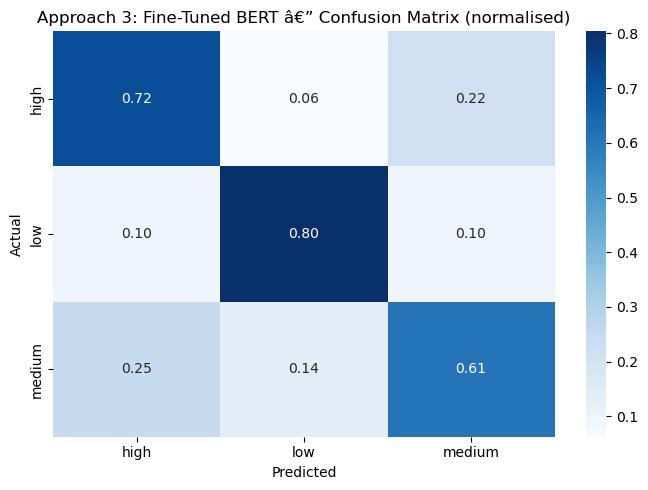

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved: outputs/task3_bert_model/
Saved: outputs/task3_bert_predictions.pkl


In [15]:
if BERT_AVAILABLE:
    print('Evaluating BERT on test set...')
    bert_model.eval()
    all_preds = []
    all_probs = []
    t0 = time.time()

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = bert_model(input_ids=input_ids,
                                 attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    bert_inf_time = time.time() - t0
    y_pred_bert   = np.array(all_preds)

    print('\nClassification Report:')
    print(classification_report(y_test_risk, y_pred_bert, target_names=risk_le.classes_))

    bert_macro_f1 = f1_score(y_test_risk, y_pred_bert, average='macro')
    bert_macro_p  = precision_score(y_test_risk, y_pred_bert, average='macro')
    bert_macro_r  = recall_score(y_test_risk, y_pred_bert, average='macro')
    bert_ms_per   = (bert_inf_time / len(test_idx)) * 1000

    print(f'Macro F1:                  {bert_macro_f1:.4f}')
    print(f'Macro Precision:           {bert_macro_p:.4f}')
    print(f'Macro Recall:              {bert_macro_r:.4f}')
    print(f'Inference time (ms/comp):  {bert_ms_per:.4f}')

    cm_bert      = confusion_matrix(y_test_risk, y_pred_bert)
    cm_bert_norm = cm_bert.astype(float) / cm_bert.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_bert_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=risk_le.classes_, yticklabels=risk_le.classes_)
    plt.title('Approach 3: Fine-Tuned BERT â€” Confusion Matrix (normalised)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('../outputs/task3_bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save fine-tuned model in Hugging Face format
    os.makedirs('../outputs/task3_bert_model', exist_ok=True)
    bert_model.save_pretrained('../outputs/task3_bert_model')
    tokenizer.save_pretrained('../outputs/task3_bert_model')
    print('\nSaved: outputs/task3_bert_model/')

    with open('../outputs/task3_bert_predictions.pkl', 'wb') as f:
        pickle.dump({'y_pred': y_pred_bert, 'y_proba': np.array(all_probs),
                     'y_test': y_test_risk, 'classes': risk_le.classes_}, f)
    print('Saved: outputs/task3_bert_predictions.pkl')

else:
    print('BERT skipped â€” torch/transformers not installed.')
    bert_macro_f1 = bert_macro_p = bert_macro_r = bert_ms_per = None

## Step 3: Model Comparison Summary

All three approaches evaluated on the same test set. **Macro Precision** and **Macro Recall** are the primary north-star metrics per the project proposal.

STEP 3: MODEL COMPARISON SUMMARY

Final Comparison Table:
                     Macro F1  Macro Precision  Macro Recall  Inference (ms/comp)
Rule-Based Baseline    0.5885           0.6343        0.7860               1.4578
Logistic Regression    0.5745           0.5914        0.5989               0.0163

Best model: Rule-Based Baseline
  Macro F1:        0.5885
  Macro Precision: 0.6343
  Macro Recall:    0.786


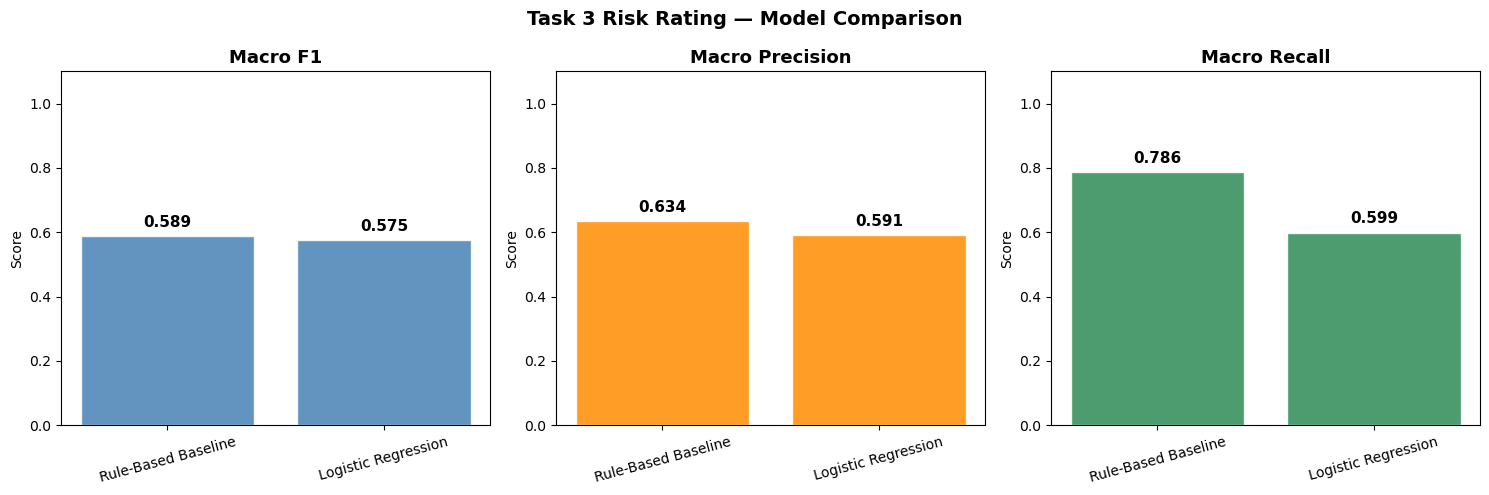


All outputs saved to outputs/:
  task3_rule_confusion_matrix.png
  task3_lr_confusion_matrix.png
  task3_lr_model.pkl
  task3_lr_predictions.pkl
  task3_model_comparison.png


In [ ]:
print('=' * 60)
print('STEP 3: MODEL COMPARISON SUMMARY')
print('=' * 60)

results = {
    'Rule-Based Baseline': {
        'Macro F1':            round(rule_macro_f1, 4),
        'Macro Precision':     round(rule_macro_p,  4),
        'Macro Recall':        round(rule_macro_r,  4),
        'Inference (ms/comp)': round(rule_ms_per,   4),
    },
    'Logistic Regression': {
        'Macro F1':            round(lr_macro_f1, 4),
        'Macro Precision':     round(lr_macro_p,  4),
        'Macro Recall':        round(lr_macro_r,  4),
        'Inference (ms/comp)': round(lr_ms_per,   4),
    },
}

if BERT_AVAILABLE and bert_macro_f1 is not None:
    results['Fine-Tuned BERT'] = {
        'Macro F1':            round(bert_macro_f1, 4),
        'Macro Precision':     round(bert_macro_p,  4),
        'Macro Recall':        round(bert_macro_r,  4),
        'Inference (ms/comp)': round(bert_ms_per,   4),
    }

comparison_df = pd.DataFrame(results).T.sort_values('Macro F1', ascending=False)

print('\nFinal Comparison Table:')
print(comparison_df.to_string())

best_name = comparison_df['Macro F1'].idxmax()
print(f'\nBest model: {best_name}')
print(f'  Macro F1:        {comparison_df.loc[best_name, "Macro F1"]}')
print(f'  Macro Precision: {comparison_df.loc[best_name, "Macro Precision"]}')
print(f'  Macro Recall:    {comparison_df.loc[best_name, "Macro Recall"]}')

# Side-by-side bar chart for the three primary metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Macro F1', 'Macro Precision', 'Macro Recall']
colors  = ['steelblue', 'darkorange', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    vals   = comparison_df[metric].astype(float)
    models = comparison_df.index
    bars   = ax.bar(models, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

plt.suptitle('Task 3 Risk Rating â€” Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/task3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll outputs saved to outputs/:')
print('  task3_rule_confusion_matrix.png')
print('  task3_lr_confusion_matrix.png')
print('  task3_lr_model.pkl')
print('  task3_lr_predictions.pkl')
if BERT_AVAILABLE and bert_macro_f1 is not None:
    print('  task3_bert_confusion_matrix.png')
    print('  task3_bert_model/')
    print('  task3_bert_predictions.pkl')
print('  task3_model_comparison.png')